In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [5]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/AVERAGE_Station_pca_variables.csv")
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/station_pca_variables.csv")
#weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
Static_contr = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")

stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)
GEV_clusters["cluster_id"] = GEV_clusters["cluster"]

label_df = GEV_clusters[["station", "cluster", "cluster_id", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station","lat", "lon"], how="inner")
model_df = model_df.merge(Static_contr, on=["station","lat", "lon", "cluster"], how="inner")

In [15]:

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "H", "id", "ID", "HYR", "GEOM", "POINT", "index", "geometry")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
#model_df = model_df.groupby("station").mean(numeric_only=True)
model_df = model_df.reset_index().groupby("station").agg(
    lambda x: x.max() if pd.api.types.is_numeric_dtype(x)
    else x.mode().iloc[0]
)
# Compute cluster sizes
cluster_counts = model_df["cluster_id"].value_counts()

# Keep only stations belonging to clusters with >1 entry
model_df = model_df[model_df["cluster_id"].isin(cluster_counts[cluster_counts > 1].index)]

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster_id']

Stations for modeling: 277
cluster
3    97
1    78
4    70
6    16
2    16
Name: count, dtype: int64


In [16]:
cat_cols

Index([], dtype='object')

In [17]:
from sklearn.preprocessing import StandardScaler
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns

X_cat = pd.get_dummies(
    X[cat_cols],
    drop_first=True,
    dtype=float
)

X_num = X[num_cols]

X = pd.concat([X_num, X_cat], axis=1)
# Keep only numeric features (RF can’t take strings unless encoded)
X = X.select_dtypes(include="number").copy()
y = model_df['cluster_id']

# handle NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_np = X.to_numpy()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

KeyError: 'CVI_Category'

In [10]:
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
def mixed_dissimilarity_matrix(X_np, cat_idx, gamma=1.0, sample_idx=None):
    """
    Mixed dissimilarity consistent with K-Prototypes objective:
      d(i,j) = ||x_num(i) - x_num(j)||^2 + gamma * (# categorical mismatches)

    Returns pairwise NxN distance matrix for the selected sample.
    """
    if sample_idx is None:
        sample_idx = np.arange(X_np.shape[0])

    Xs = X_np[sample_idx]
    n, p = Xs.shape

    cat_mask = np.zeros(p, dtype=bool)
    cat_mask[cat_idx] = True
    num_mask = ~cat_mask

    # numeric part
    X_num = Xs[:, num_mask].astype(float, copy=False)
    xx = (X_num ** 2).sum(axis=1, keepdims=True)
    D_num = xx + xx.T - 2.0 * (X_num @ X_num.T)
    D_num = np.maximum(D_num, 0.0)

    # categorical part: mismatch counts
    X_cat = Xs[:, cat_mask].astype(str, copy=False)
    D_cat = np.zeros((n, n), dtype=float)
    for j in range(X_cat.shape[1]):
        col = X_cat[:, j]
        D_cat += (col[:, None] != col[None, :]).astype(float)

    D = D_num + gamma * D_cat
    np.fill_diagonal(D, 0.0)
    return D

# --- Choose k via cost + silhouette (sampled to avoid O(n^2) blow-up) ---
ks = range(2, 20)
costs = []
sils = []

n_total = X_np.shape[0]
sample_n = min(2000, n_total)          # increase if feasible
rng = np.random.default_rng(0)
sample_idx = rng.choice(n_total, size=sample_n, replace=False)

for k in ks:
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=10, random_state=0, verbose=0)
    labels = kp.fit_predict(X_np, categorical=cat_idx)

    costs.append(kp.cost_)

    # use the gamma learned/used by this model if available
    gamma = getattr(kp, "gamma_", getattr(kp, "gamma", 1.0))

    # silhouette on sample (precomputed mixed dissimilarity)
    D = mixed_dissimilarity_matrix(X_np, cat_idx, gamma=gamma, sample_idx=sample_idx)
    sils.append(silhouette_score(D, labels[sample_idx], metric="precomputed"))

# Plot both
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(list(ks), costs, marker="o")
ax[0].set_title("K-Prototypes cost (elbow)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Cost")

ax[1].plot(list(ks), sils, marker="o")
ax[1].set_title(f"Silhouette (mixed distance) on n={sample_n}")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(sils))]
print("Best k by silhouette:", best_k)


NameError: name 'cat_idx' is not defined

In [325]:
# --- Fit final model (pick k; here: the elbow manually, or use your own choice) ---
best_k = 13
kp_final = KPrototypes(n_clusters=best_k, init="Huang", n_init=20, random_state=0, verbose=0)
model_df["kproto_cluster"] = kp_final.fit_predict(X_np, categorical=cat_idx)

print("Chosen k:", best_k)
print(model_df["kproto_cluster"].value_counts())

Chosen k: 13
kproto_cluster
6     62
7     45
1     37
5     27
4     24
2     21
3     16
12    15
9     12
11     7
0      6
10     4
8      1
Name: count, dtype: int64


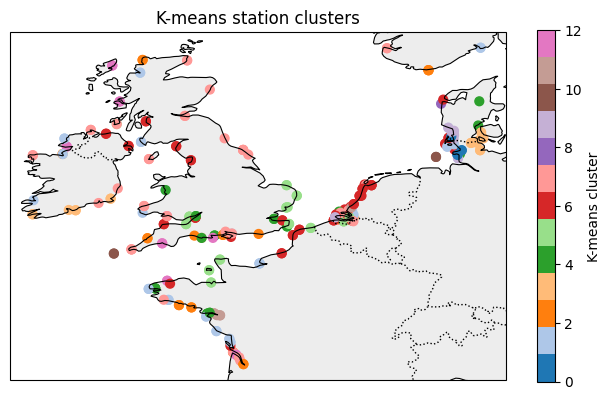

In [342]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white")

clusters = sorted(model_df["kproto_cluster"].unique())
n = len(clusters)

colors = sns.color_palette("tab20", n)
cmap = mcolors.ListedColormap(colors)

sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["kproto_cluster"],
    cmap=cmap,
    s=40,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label="K-means cluster", shrink=0.57)
ax.set_title("K-means station clusters")
plt.show()

In [327]:
import pandas as pd

ct = pd.crosstab(model_df["kproto_cluster"], model_df["cluster_id"])

# For each proto cluster → take best matching reference cluster
best_matches = ct.max(axis=1)

agreement_pct = best_matches.sum() / len(model_df) * 100

print(f"Robust agreement (many→one mapping): {agreement_pct:.1f}%")


Robust agreement (many→one mapping): 53.8%


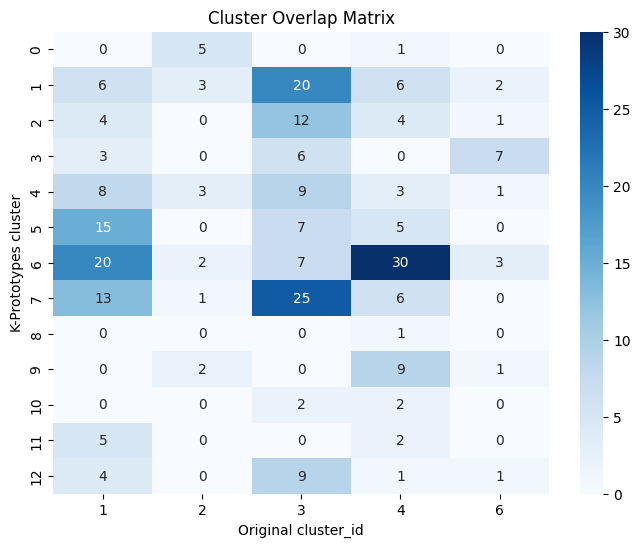

In [328]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster Overlap Matrix")
plt.xlabel("Original cluster_id")
plt.ylabel("K-Prototypes cluster")
plt.show()


In [378]:
# Keep only necessary columns
cluster_labels = model_df[["kproto_cluster"]].copy()

# Ensure same index key (usually station)
weather_df = weathercluster_df.copy()

# If both are indexed by station:
merged = weather_df.join(cluster_labels, how="outer")

print("Merged shape:", merged.shape)


Merged shape: (51012, 20)


In [379]:
num_features = merged.select_dtypes(include="number").columns.tolist()
num_features.remove("kproto_cluster")
num_features.remove("cluster")
num_features.remove("lat")
num_features.remove("lon")
num_features.remove("station")
num_features.remove("Unnamed: 0.1")
num_features.remove("Unnamed: 0")

In [381]:
from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon
import numpy as np

def kde_js_similarity(x, y):
    """Return similarity between two distributions using KDE."""
    xmin = min(x.min(), y.min())
    xmax = max(x.max(), y.max())

    grid = np.linspace(xmin, xmax, 200)

    kde_x = gaussian_kde(x)(grid)
    kde_y = gaussian_kde(y)(grid)

    # Normalize densities
    kde_x /= kde_x.sum()
    kde_y /= kde_y.sum()

    js_dist = jensenshannon(kde_x, kde_y)
    return 1 - js_dist


In [382]:
from numpy.linalg import LinAlgError

results = []

for var in num_features:
    for cid in merged["cluster"].unique():
        if cid in [0, 5]:
            continue
        else:

            for pid in merged["kproto_cluster"].unique():

                x = merged.loc[merged["cluster"] == cid, var].dropna()
                y = merged.loc[merged["kproto_cluster"] == pid, var].dropna()

                # Skip if insufficient data
                if len(x) < 10 or len(y) < 10:
                    continue

                # Skip degenerate distributions
                if x.nunique() < 2 or y.nunique() < 2:
                    continue

                try:
                    sim = kde_js_similarity(x, y)

                    results.append({
                        "variable": var,
                        "cluster": cid,
                        "kproto_cluster": pid,
                        "similarity": sim
                    })

                except LinAlgError:
                # KDE covariance singular → skip safely
                    continue
                except Exception:
                # Catch any other numerical issues
                    continue

overlap_df = pd.DataFrame(results)


In [476]:
merged.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'wind_wave_alignment', 'lat', 'tp', 'lon',
       'mwd', 'mwp', 'wind_dir', 'v10_abs', 'tau_v', 'msl', 'sp', 'v10',
       'u10_abs', 'swh', 'station', 'extract_time', 'cluster',
       'kproto_cluster'],
      dtype='object')

In [475]:
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.linalg import LinAlgError
pid=4
var = "u10_abs"#"sp"# "wind_wave_alignment"
x = merged.loc[merged["cluster"] == cid, var].dropna()
y = merged.loc[merged["kproto_cluster"] == pid, var].dropna()
sim = kde_js_similarity(x, y)
plt.figure(figsize=(7,4))

try:
    sns.kdeplot(x, label=f"cluster {cid} (n={len(x)})", linewidth=2)
    sns.kdeplot(y, label=f"kproto {pid} (n={len(y)})", linewidth=2)

    plt.title(f"KDE overlap: {var}\nJS-similarity = {sim:.2f}")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

except LinAlgError:
    plt.close()
    print("KDE failed due to singular covariance for this example — pick another row.")


ValueError: `dataset` input should have multiple elements.

In [435]:
# Sort so highest similarities come first
df_sorted = overlap_df.sort_values("similarity", ascending=False)

# Take top 3 variables per cluster pair
top3_per_pair = (
    df_sorted
    .groupby(["cluster", "kproto_cluster"])
    .head(3)
)

cluster_similarity_top3 = (
    top3_per_pair
    .groupby(["cluster", "kproto_cluster"])["similarity"]
    .mean()
    .unstack()
)

top_matches = cluster_similarity_top3.apply(
    lambda row: row.nlargest(3).index.tolist(),
    axis=1
)

rows = []

for cid, proto_list in top_matches.items():
    for pid in proto_list:

        subset = top3_per_pair[
            (top3_per_pair["cluster"] == cid) &
            (top3_per_pair["kproto_cluster"] == pid)
        ].sort_values("similarity", ascending=False)

        for _, r in subset.iterrows():
            rows.append({
                "cluster": cid,
                "kproto_cluster": pid,
                "variable": r["variable"],
                "similarity": r["similarity"]
            })

overlap_explanation = pd.DataFrame(rows)
for cid in overlap_explanation["cluster"].unique():

    print(f"\n===== Original Cluster {cid} =====")

    dfc = overlap_explanation[overlap_explanation["cluster"] == cid]

    for pid in dfc["kproto_cluster"].unique():

        print(f"\n  ↳ Best Proto Cluster {pid}")

        sub = dfc[dfc["kproto_cluster"] == pid]

        for _, r in sub.iterrows():
            print(f"     {r['variable']}  → similarity {r['similarity']:.2f}")



===== Original Cluster 1 =====

  ↳ Best Proto Cluster 9.0
     u10_abs  → similarity 0.94
     tau_v  → similarity 0.90
     msl  → similarity 0.89

  ↳ Best Proto Cluster 1.0
     sp  → similarity 0.91
     msl  → similarity 0.89
     wind_wave_alignment  → similarity 0.88

  ↳ Best Proto Cluster 2.0
     sp  → similarity 0.89
     msl  → similarity 0.86
     u10_abs  → similarity 0.84

===== Original Cluster 2 =====

  ↳ Best Proto Cluster 1.0
     wind_wave_alignment  → similarity 0.90
     u10_abs  → similarity 0.83
     v10_abs  → similarity 0.74

  ↳ Best Proto Cluster 7.0
     wind_wave_alignment  → similarity 0.88
     u10_abs  → similarity 0.80
     msl  → similarity 0.66

  ↳ Best Proto Cluster 6.0
     wind_wave_alignment  → similarity 0.82
     u10_abs  → similarity 0.80
     msl  → similarity 0.70

===== Original Cluster 3 =====

  ↳ Best Proto Cluster 1.0
     wind_wave_alignment  → similarity 0.89
     sp  → similarity 0.88
     msl  → similarity 0.87

  ↳ Best Proto C

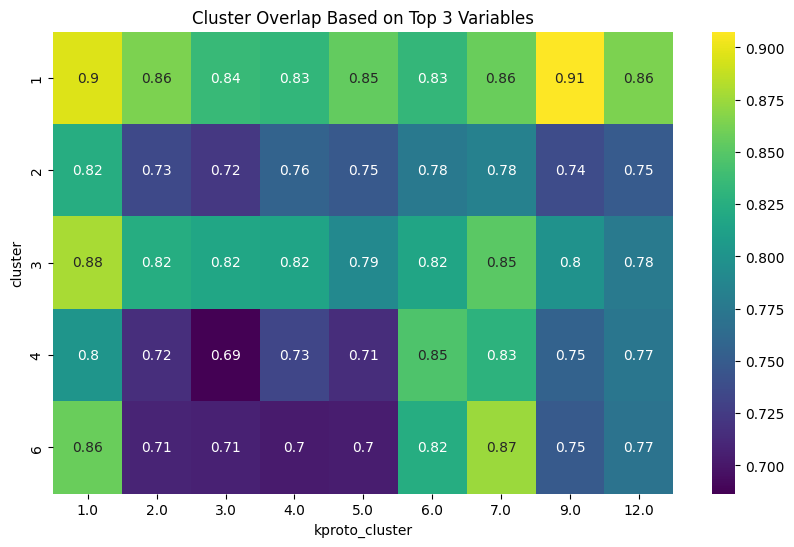

In [436]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cluster_similarity_top3, annot=True, cmap="viridis")
plt.title("Cluster Overlap Based on Top 3 Variables")
plt.show()


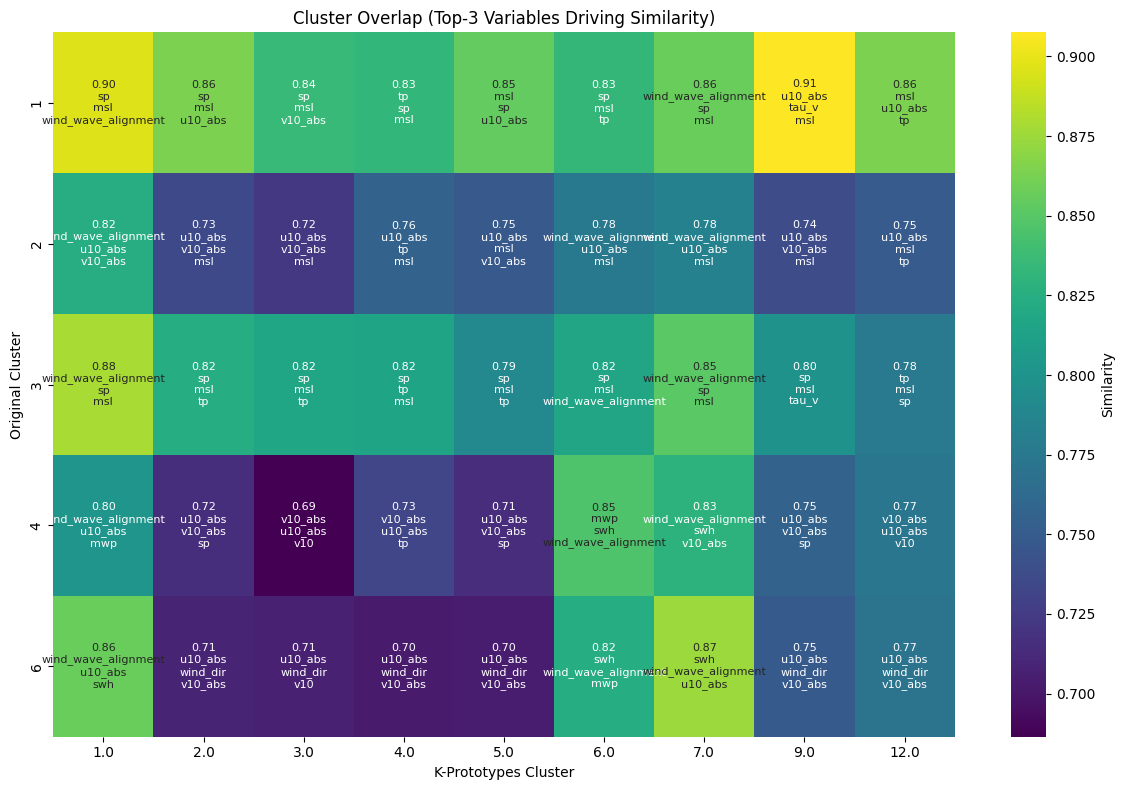

In [440]:
# Create annotation text matrix
annot_matrix = cluster_similarity_top3.copy().astype(str)

for cid in cluster_similarity_top3.index:
    for pid in cluster_similarity_top3.columns:

        subset = top3_per_pair[
            (top3_per_pair["cluster"] == cid) &
            (top3_per_pair["kproto_cluster"] == pid)
        ]

        if subset.empty:
            annot_matrix.loc[cid, pid] = ""
            continue

        vars_list = subset["variable"].tolist()
        score = cluster_similarity_top3.loc[cid, pid]

        annot_matrix.loc[cid, pid] = (
            f"{score:.2f}\n" +
            "\n".join(vars_list)
        )
        
plt.figure(figsize=(12,8))

sns.heatmap(
    cluster_similarity_top3,
    annot=annot_matrix,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "Similarity"},
    annot_kws={"size": 8}
)

plt.title("Cluster Overlap (Top-3 Variables Driving Similarity)")
plt.xlabel("K-Prototypes Cluster")
plt.ylabel("Original Cluster")
plt.tight_layout()
plt.show()



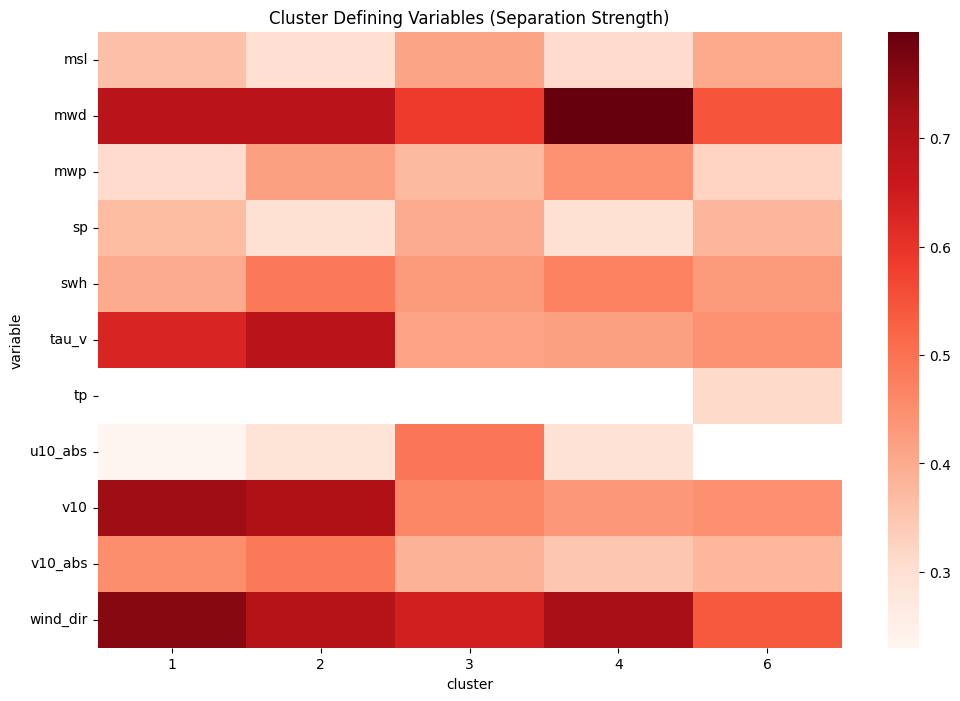

In [443]:
signature_rows = []

clusters = merged["cluster"].unique()

for var in num_features:

    for cid in clusters:

        if cid in [0, 5]:   # keep your exclusion
            continue

        x = merged.loc[merged["cluster"] == cid, var].dropna()

        if len(x) < 15 or x.nunique() < 2:
            continue

        similarities = []

        for other in clusters:
            if other == cid or other in [0, 5]:
                continue

            y = merged.loc[merged["cluster"] == other, var].dropna()

            if len(y) < 15 or y.nunique() < 2:
                continue

            try:
                sim = kde_js_similarity(x, y)
                similarities.append(sim)

            except:
                continue

        if len(similarities) == 0:
            continue

        # Separation = how different from others
        separation = 1 - np.mean(similarities)

        signature_rows.append({
            "cluster": cid,
            "variable": var,
            "separation_score": separation,
            "avg_similarity_to_others": np.mean(similarities)
        })

signature_df = pd.DataFrame(signature_rows)
top_signatures = (
    signature_df
    .sort_values(["cluster", "separation_score"], ascending=[True, False])
    .groupby("cluster")
    .head(10)
)

top_signatures.head(20)

pivot_sig = top_signatures.pivot_table(
    index="variable",
    columns="cluster",
    values="separation_score"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot_sig, cmap="Reds")
plt.title("Cluster Defining Variables (Separation Strength)")
plt.show()


signature_rows = []

clusters = merged["kproto_cluster"].unique()

for var in num_features:

    for cid in clusters:

        if cid in [0, 5]:   # keep your exclusion
            continue

        x = merged.loc[merged["kproto_cluster"] == cid, var].dropna()

        if len(x) < 15 or x.nunique() < 2:
            continue

        similarities = []

        for other in clusters:
            if other == cid or other in [0, 5]:
                continue

            y = merged.loc[merged["kproto_cluster"] == other, var].dropna()

            if len(y) < 15 or y.nunique() < 2:
                continue

            try:
                sim = kde_js_similarity(x, y)
                similarities.append(sim)

            except:
                continue

        if len(similarities) == 0:
            continue

        # Separation = how different from others
        separation = 1 - np.mean(similarities)

        signature_rows.append({
            "cluster": cid,
            "variable": var,
            "separation_score": separation,
            "avg_similarity_to_others": np.mean(similarities)
        })

signature_df = pd.DataFrame(signature_rows)
top_signatures = (
    signature_df
    .sort_values(["cluster", "separation_score"], ascending=[True, False])
    .groupby("cluster")
    .head(10)
)

top_signatures.head(20)

pivot_sig = top_signatures.pivot_table(
    index="variable",
    columns="cluster",
    values="separation_score"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot_sig, cmap="Reds")
plt.title("Cluster Defining Variables (Separation Strength)")
plt.show()

In [448]:
# Ensure model_df is indexed by station
if "station" in model_df.columns:
    model_static = model_df.set_index("station")
else:
    model_static = model_df.copy()

# keep only static columns you want (exclude labels and coordinates etc.)
static_cols = [c for c in model_static.columns
               if c not in ["cluster", "cluster_id", "kproto_cluster", "lat", "lon"]]

merged2 = merged.join(model_static[static_cols], how="left")


ValueError: columns overlap but no suffix specified: Index(['Unnamed: 0.1'], dtype='object')

kproto_cluster      1.0       2.0       3.0       4.0       5.0       6.0   \
cluster                                                                      
1               0.896194  0.864090  0.835499  0.831610  0.854852  0.832672   
2               0.823942  0.734886  0.722669  0.756206  0.747660  0.775673   
3               0.878446  0.823138  0.817594  0.815693  0.790818  0.816281   
4               0.801536  0.715239  0.686479  0.733044  0.714565  0.845414   
6               0.856777  0.708252  0.706742  0.702201  0.703752  0.823722   

kproto_cluster      7.0       9.0       12.0  
cluster                                       
1               0.857173  0.907569  0.863706  
2               0.782592  0.737406  0.748938  
3               0.850579  0.798249  0.777069  
4               0.828708  0.754936  0.773213  
6               0.874726  0.748452  0.770522  


In [424]:
cluster_similarity = (
    overlap_df
    .groupby(["cluster", "kproto_cluster"])["similarity"]
    .mean()
    .unstack()
)

print(cluster_similarity)


kproto_cluster      1.0       2.0       3.0       4.0       5.0       6.0   \
cluster                                                                      
1               0.720903  0.774882  0.702928  0.742782  0.742029  0.673189   
2               0.574190  0.546675  0.574862  0.580266  0.570097  0.544316   
3               0.646925  0.653704  0.666044  0.679480  0.669457  0.630735   
4               0.656713  0.599133  0.596586  0.641324  0.611201  0.691841   
6               0.638093  0.566146  0.555012  0.594395  0.584791  0.658440   

kproto_cluster      7.0       9.0       12.0  
cluster                                       
1               0.704669  0.778746  0.720982  
2               0.555724  0.538533  0.591628  
3               0.658975  0.649150  0.690076  
4               0.660087  0.634779  0.669411  
6               0.659268  0.596236  0.629380  


In [425]:
top2_matches = cluster_similarity.apply(
    lambda row: row.nlargest(3).index.tolist(),
    axis=1
)
top2_matches

cluster
1     [9.0, 2.0, 4.0]
2    [12.0, 4.0, 3.0]
3    [12.0, 4.0, 5.0]
4    [6.0, 12.0, 7.0]
6     [7.0, 6.0, 1.0]
dtype: object

In [426]:
var_sep = overlap_df.groupby("variable")["similarity"].mean().sort_values()
print(var_sep.head(15))


variable
mwd                    0.508754
wind_dir               0.512867
v10                    0.529232
tau_v                  0.545739
swh                    0.596767
tp                     0.660324
v10_abs                0.668555
mwp                    0.694461
msl                    0.707468
sp                     0.708493
u10_abs                0.765637
wind_wave_alignment    0.858044
Name: similarity, dtype: float64


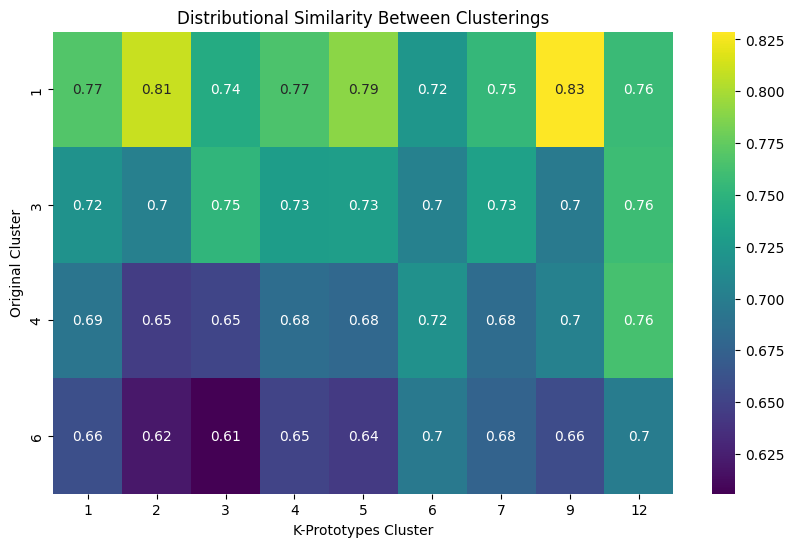

In [366]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(cluster_similarity, annot=True, cmap="viridis")
plt.title("Distributional Similarity Between Clusterings")
plt.xlabel("K-Prototypes Cluster")
plt.ylabel("Original Cluster")
plt.show()


In [284]:
cluster_means = merged.groupby("kproto_cluster")[num_features].mean()

importance = cluster_means.var().sort_values(ascending=False)

top_vars = importance.head(12).index.tolist()

print("Most separating weather features:")
print(top_vars)


Most separating weather features:
['sp', 'msl', 'Unnamed: 0.1', 'Unnamed: 0', 'wind_dir', 'mwd', 'station', 'v10_abs', 'v10', 'u10_abs', 'lon', 'cluster']


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


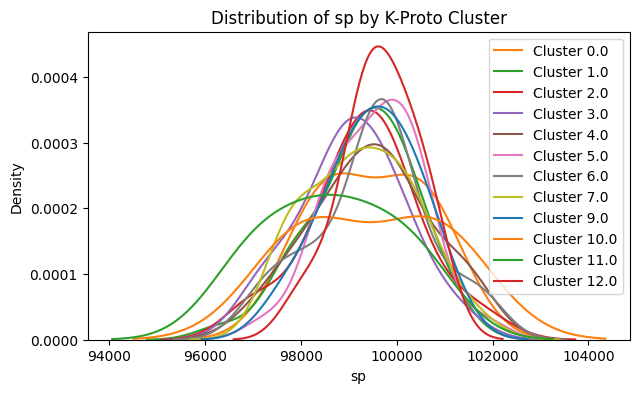

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


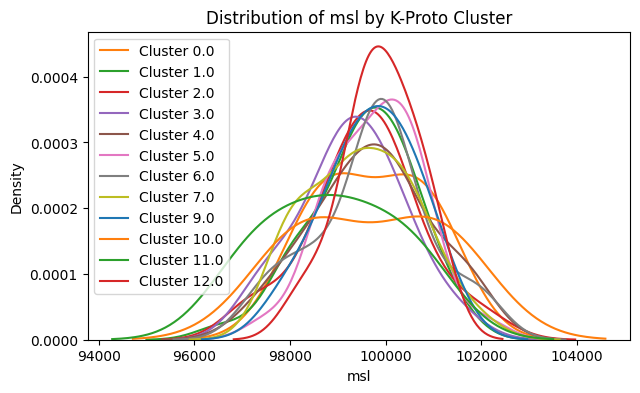

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


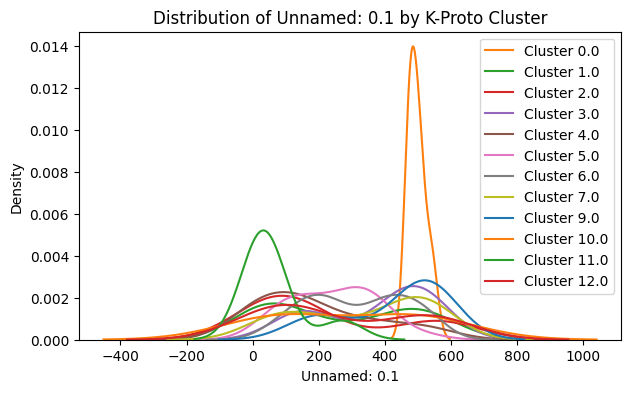

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


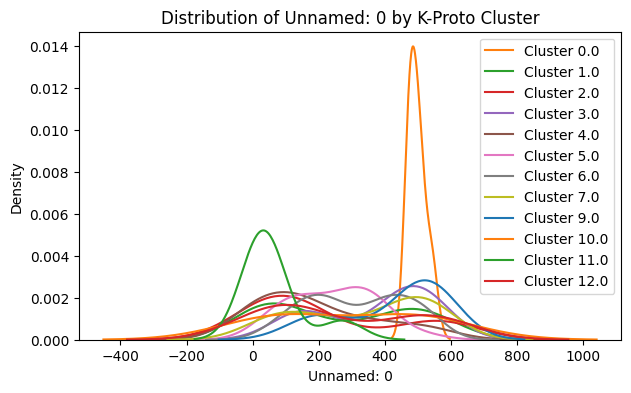

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


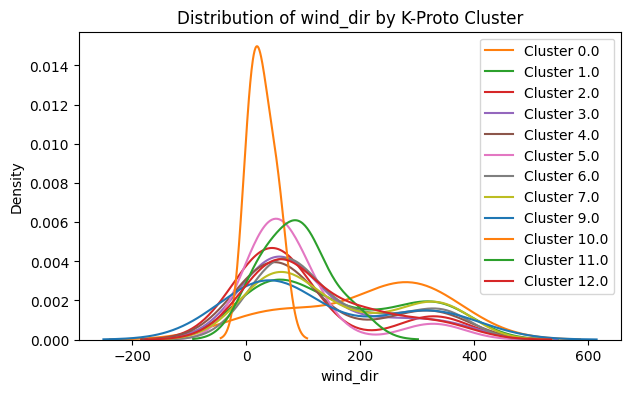

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76378/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


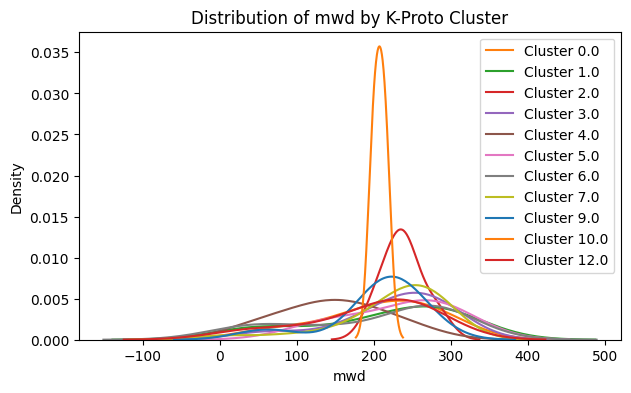

In [449]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in top_vars[:6]:  # plot top 6 first
    plt.figure(figsize=(7,4))

    for c in sorted(merged["kproto_cluster"].unique()):
        subset = merged[merged["kproto_cluster"] == c][var]
        sns.kdeplot(subset, label=f"Cluster {c}", fill=False)

    plt.title(f"Distribution of {var} by K-Proto Cluster")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


In [453]:
from sklearn.metrics import normalized_mutual_info_score

nmi = normalized_mutual_info_score(
    model_df["cluster_id"],
    model_df["kproto_cluster"]
)

print("NMI:", nmi)
print("so quite independent")


NMI: 0.16807186792525874
so quite independent


In [451]:
ct = pd.crosstab(
    model_df["cluster_id"],
    model_df["kproto_cluster"]
)
print(ct)

kproto_cluster  0   1   2   3   4   5   6   7   8   9   10  11  12
cluster_id                                                        
1                0   6   4   3   8  15  20  13   0   0   0   5   4
2                5   3   0   0   3   0   2   1   0   2   0   0   0
3                0  20  12   6   9   7   7  25   0   0   2   0   9
4                1   6   4   0   3   5  30   6   1   9   2   2   1
6                0   2   1   7   1   0   3   0   0   1   0   0   1


Best-match overlap: 31.4%


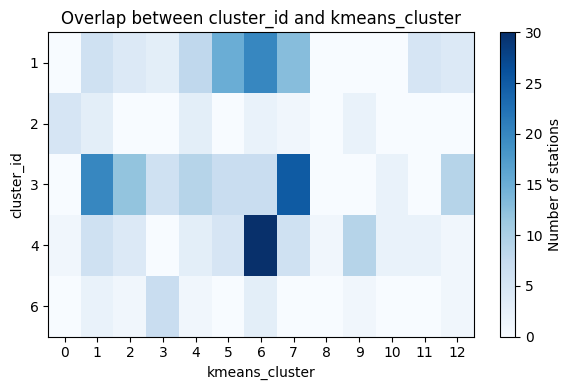

In [454]:
best_match_pct = ct.max(axis=1).sum() / ct.values.sum() * 100
print(f"Best-match overlap: {best_match_pct:.1f}%")

plt.figure(figsize=(6, 4))
plt.imshow(ct, aspect="auto", cmap="Blues")
plt.colorbar(label="Number of stations")

plt.yticks(range(len(ct.index)), ct.index)
plt.xticks(range(len(ct.columns)), ct.columns)
plt.xlabel("kmeans_cluster")
plt.ylabel("cluster_id")
plt.title("Overlap between cluster_id and kmeans_cluster")

plt.tight_layout()
plt.show()

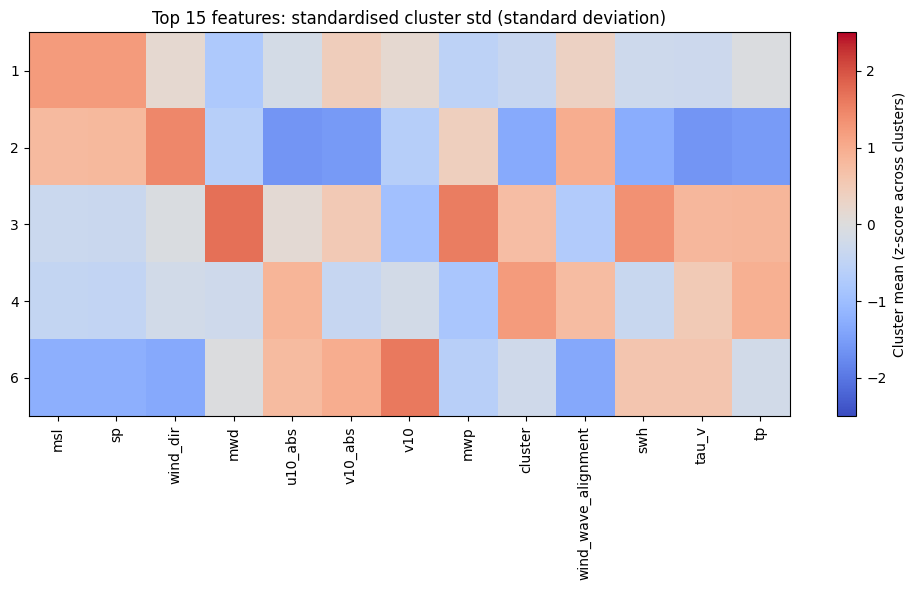

In [470]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cluster = model_df["cluster_id"]
df = X.copy()
df["kmodes_cluster"] = cluster.values
df = df.loc[:, ~df.columns.str.contains("Unnamed", case=False)]
df = df.loc[:, ~df.columns.str.contains("station", case=False)]
df = df.loc[:, ~df.columns.str.contains("lat", case=False)]
df = df.loc[:, ~df.columns.str.contains("lon", case=False)]
# Per-cluster summary
means = df.groupby("kmodes_cluster").mean(numeric_only=True)
stds  = df.groupby("kmodes_cluster").std(numeric_only=True)
counts = df.groupby("kmodes_cluster").size()
var_score = means.std(axis=0)

top_n = 15
top_features = var_score.sort_values(ascending=False).head(top_n).index

means_top = means[top_features]
stds_top  = stds[top_features]

# Z-score across clusters (per feature)
Z = (means_top - means_top.mean(axis=0)) / (means_top.std(axis=0) + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(Z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.colorbar(label="Cluster mean (z-score across clusters)")

plt.yticks(range(len(Z.index)), Z.index)
plt.xticks(range(len(Z.columns)), Z.columns, rotation=90)
plt.title(f"Top {top_n} features: standardised cluster std (standard deviation)")
plt.tight_layout()
plt.show()

In [194]:


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# standardize (MANDATORY for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = model_df['cluster_id']

In [195]:
from sklearn.preprocessing import StandardScaler

X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

# one-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# numeric only
X = X.select_dtypes(include="number")

# handle NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# standardize (MANDATORY for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = model_df['cluster_id']

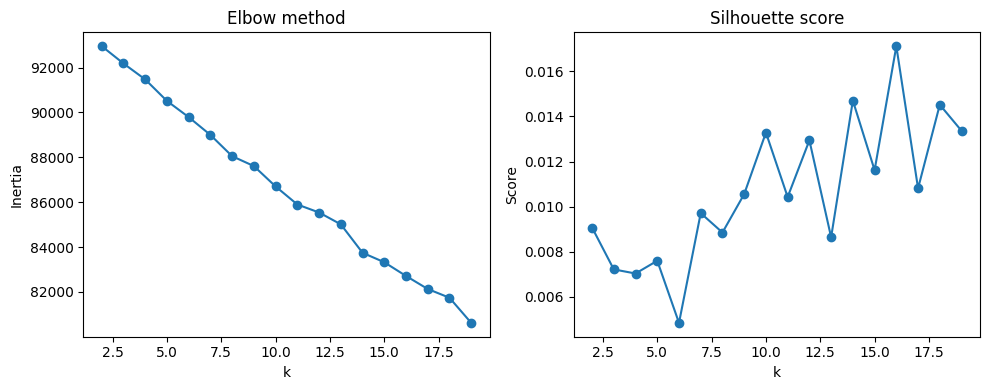

In [240]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

ks = range(2, 20)
inertia = []
silhouette = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=0)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, silhouette, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [197]:
k_opt = 8

kmeans = KMeans(n_clusters=k_opt, n_init=50, random_state=0)
model_df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)


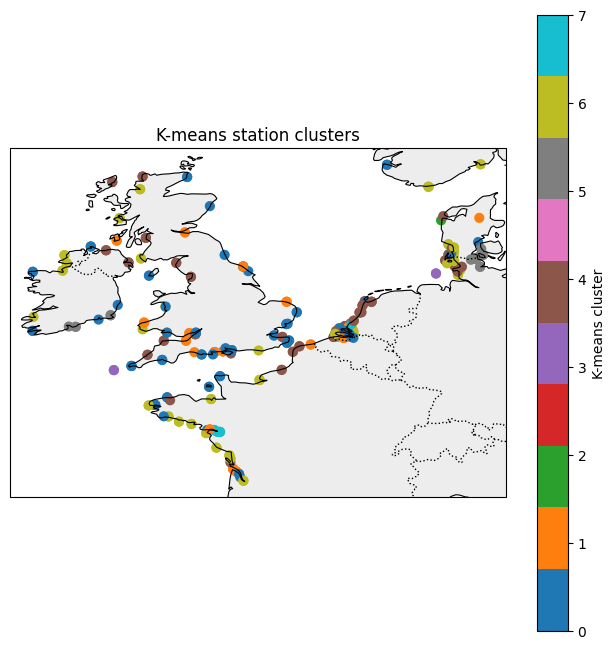

In [199]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white")

sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["kmeans_cluster"],
    cmap="tab10",
    s=40,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label="K-means cluster")
ax.set_title("K-means station clusters")
plt.show()


In [200]:
agreement_pct = (model_df["cluster_id"] == model_df["kmeans_cluster"]).mean() * 100
print(f"Exact label agreement: {agreement_pct:.1f}%")


Exact label agreement: 19.9%


In [201]:
ct = pd.crosstab(
    model_df["cluster_id"],
    model_df["kmeans_cluster"]
)
print(ct)


kmeans_cluster   0   1  2  3   4  5   6  7
cluster_id                                
1               22  16  0  0  22  3  10  5
2                3   0  0  0   7  0   6  0
3               36  13  0  2   9  5  32  0
4                9   7  1  2  33  0  16  2
6                1   1  0  0   3  7   4  0


In [ ]:
best_match_pct = ct.max(axis=1).sum() / ct.values.sum() * 100
print(f"Best-match overlap: {best_match_pct:.1f}%")


Best-match overlap: 37.9%


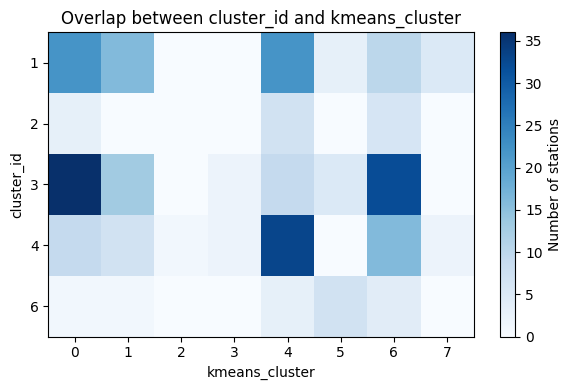

In [203]:
plt.figure(figsize=(6, 4))
plt.imshow(ct, aspect="auto", cmap="Blues")
plt.colorbar(label="Number of stations")

plt.yticks(range(len(ct.index)), ct.index)
plt.xticks(range(len(ct.columns)), ct.columns)
plt.xlabel("kmeans_cluster")
plt.ylabel("cluster_id")
plt.title("Overlap between cluster_id and kmeans_cluster")

plt.tight_layout()
plt.show()


In [228]:
from sklearn.feature_selection import f_classif

f_scores, _ = f_classif(X_scaled, y)

importance = (
    pd.Series(f_scores, index=model_df.columns)
    .sort_values(ascending=False)
)

print(importance.head(15))


ValueError: Length of values (33) does not match length of index (59)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cluster = model_df["cluster_id"]
df = X.copy()
df["kmeans_cluster"] = cluster.values

# Per-cluster summary
means = df.groupby("kmeans_cluster").mean(numeric_only=True)
stds  = df.groupby("kmeans_cluster").std(numeric_only=True)
counts = df.groupby("kmeans_cluster").size()

# Variation across clusters (on the cluster means)
# Option A: range of means
#var_score = (means.max(axis=0) - means.min(axis=0))

# Option B (often nicer): std of means (between-cluster spread)
var_score = means.std(axis=0)

top_n = 25
top_features = var_score.sort_values(ascending=False).head(top_n).index

means_top = means[top_features]
stds_top  = stds[top_features]

# Z-score across clusters (per feature)
Z = (means_top - means_top.mean(axis=0)) / (means_top.std(axis=0) + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(Z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.colorbar(label="Cluster mean (z-score across clusters)")

plt.yticks(range(len(Z.index)), Z.index)
plt.xticks(range(len(Z.columns)), Z.columns, rotation=90)
plt.title(f"Top {top_n} features: standardided cluster std")
plt.tight_layout()
plt.show()


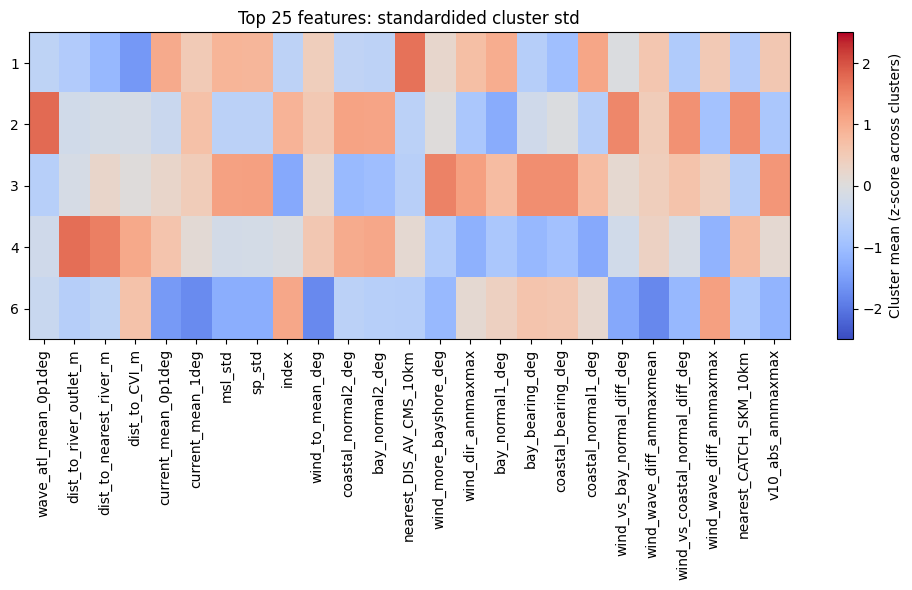

In [205]:
# Z-score across clusters (per feature)
Z = (means_top - means_top.mean(axis=0)) / (means_top.std(axis=0) + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(Z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.colorbar(label="Cluster mean (z-score across clusters)")

plt.yticks(range(len(Z.index)), Z.index)
plt.xticks(range(len(Z.columns)), Z.columns, rotation=90)
plt.title(f"Top {top_n} features: standardided cluster std")
plt.tight_layout()
plt.show()


In [206]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

In [207]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500
)

logreg.fit(X_train, y_train)

print("Train accuracy:", logreg.score(X_train, y_train))
print("Test accuracy :", logreg.score(X_test, y_test))
import pandas as pd
import numpy as np

coef = np.abs(logreg.coef_)  # shape: (n_clusters, n_features)

importance_logreg = pd.Series(
    coef.mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nTop linear predictors:\n")
print(importance_logreg.head(10))


Train accuracy: 0.7874396135265701
Test accuracy : 0.5714285714285714

Top linear predictors:

wind_dir_annmaxmax             0.847466
current_mean_1deg              0.599323
wave_nc_mean_0p1deg            0.532698
v10_abs_annmaxmax              0.531382
index                          0.492369
wind_wave_alignment_q99        0.459199
nearest_CATCH_SKM_10km         0.447439
wind_vs_bay_normal_diff_deg    0.440957
coastal_normal2_deg            0.397510
current_mean_0p1deg            0.385623
dtype: float64


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [208]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=5,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("RF train accuracy:", rf.score(X_train, y_train))
print("RF test accuracy :", rf.score(X_test, y_test))


RF train accuracy: 0.9468599033816425
RF test accuracy : 0.7428571428571429


In [209]:
importance_rf = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop RF predictors:\n")
print(importance_rf.head(10))



Top RF predictors:

v10_abs_annmaxmax            0.102028
wind_dir_annmaxmax           0.080456
current_mean_1deg            0.067304
index                        0.066613
current_mean_0p1deg          0.059979
wave_nc_mean_0p1deg          0.057993
wave_atl_mean_0p1deg         0.050223
wind_to_mean_deg             0.033323
wind_wave_diff_annmaxmean    0.031640
sp_std                       0.027365
dtype: float64


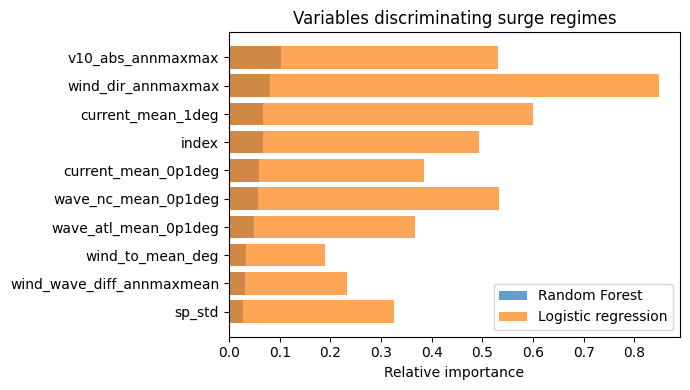

In [210]:
top_n = 10
vars_top = importance_rf.head(top_n).index

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    vars_top,
    importance_rf.loc[vars_top],
    alpha=0.7,
    label="Random Forest"
)

ax.barh(
    vars_top,
    importance_logreg.loc[vars_top],
    alpha=0.7,
    label="Logistic regression"
)

ax.invert_yaxis()
ax.set_xlabel("Relative importance")
ax.set_title("Variables discriminating surge regimes")
ax.legend()

plt.tight_layout()
plt.show()


In [211]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_perm = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("\nTop permutation importances:\n")
print(importance_perm.head(10))



Top permutation importances:

wind_dir_annmaxmax         0.083571
v10_abs_annmaxmax          0.052143
wind_wave_alignment_q99    0.030714
wave_atl_mean_0p1deg       0.027857
index                      0.026429
nearest_CATCH_SKM_10km     0.023571
dist_to_river_outlet_m     0.022143
current_mean_0p1deg        0.020714
dist_to_nearest_river_m    0.020000
bay_normal1_deg            0.020000
dtype: float64


In [212]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

cluster_ids = np.unique(y_train)
cluster_importances = {}

for k in cluster_ids:
    # One-vs-rest labels
    y_train_k = (y_train == k).astype(int)
    y_test_k  = (y_test  == k).astype(int)

    rf_k = RandomForestClassifier(
        n_estimators=800,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=5,
        n_jobs=-1
    )
    rf_k.fit(X_train, y_train_k)

    perm = permutation_importance(
        rf_k,
        X_test,
        y_test_k,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    cluster_importances[k] = pd.Series(
        perm.importances_mean,
        index=X.columns
    ).sort_values(ascending=False)

# Example: top variables for cluster 2
print("\nTop variables separating cluster 2:\n")
print(cluster_importances[2].head(10))



Top variables separating cluster 2:

wave_nc_mean_0p1deg            0.032857
v10_abs_annmaxmax              0.017143
index                          0.000000
wind_vs_bay_normal_diff_deg    0.000000
nearest_CATCH_SKM_10km         0.000000
dist_to_nearest_river_m        0.000000
dist_to_river_outlet_m         0.000000
current_mean_1deg              0.000000
current_mean_0p1deg            0.000000
wave_atl_mean_0p1deg           0.000000
dtype: float64


In [213]:
1-4

-3

In [214]:
print(cluster_importances[1].head(10))

nearest_DIS_AV_CMS_10km      0.037143
v10_abs_annmaxmax            0.030714
wind_wave_diff_annmaxmean    0.020714
index                        0.017857
wind_wave_alignment_q99      0.015714
msl_std                      0.015714
sp_std                       0.015000
wind_dir_annmaxmax           0.015000
coastal_bearing_deg          0.014286
coastal_normal1_deg          0.014286
dtype: float64


 99%|===================| 345/350 [00:14<00:00]        

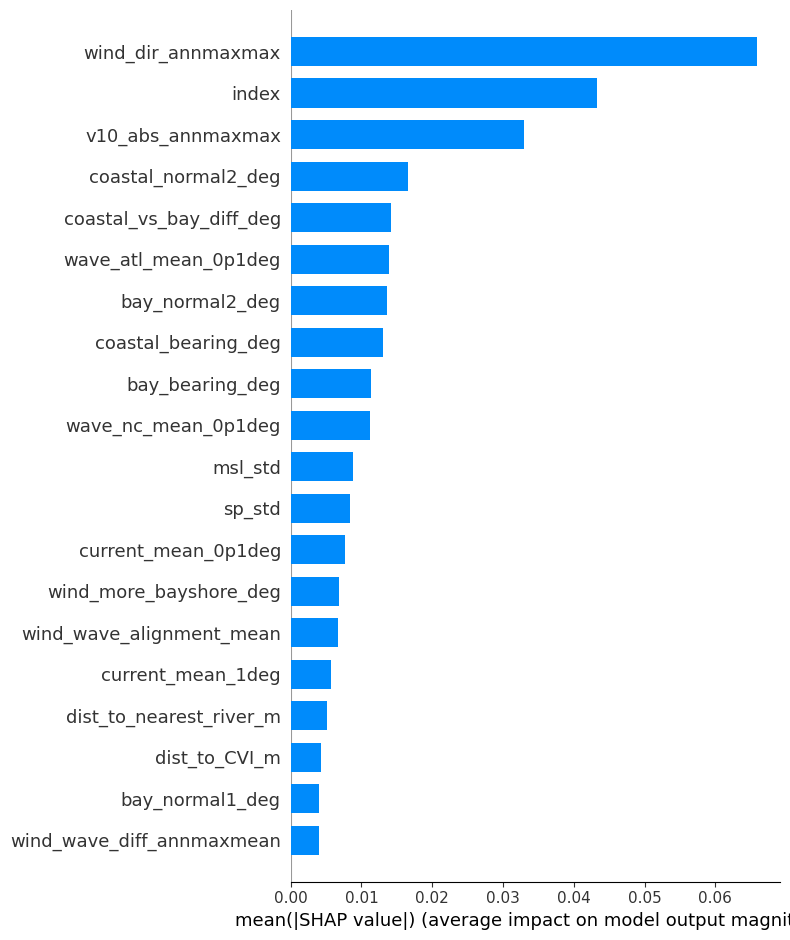

In [215]:
import shap
k = 2
explainer = shap.Explainer(rf, X_train)
shap_exp = explainer(X_test)

# shap_exp.values shape:
# (n_samples, n_features, n_classes)
k = 2
# Select cluster k
shap_k = shap_exp[:, :, k]

shap.summary_plot(
    shap_k,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

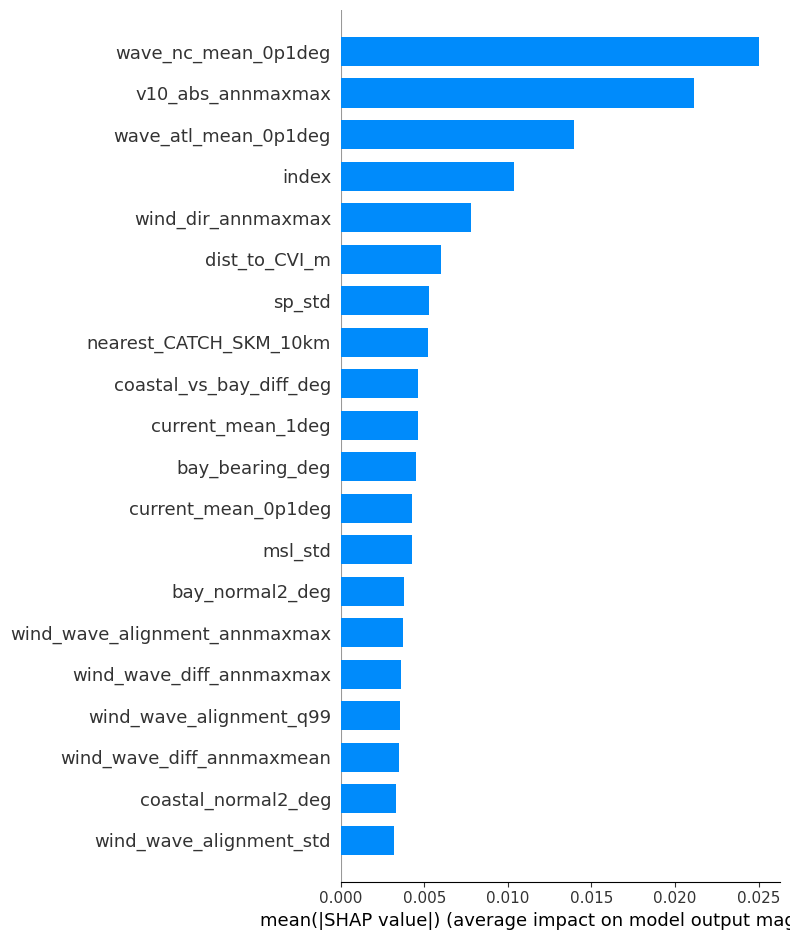

In [216]:
k = 1
# Select cluster k
shap_k = shap_exp[:, :, k]

shap.summary_plot(
    shap_k,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

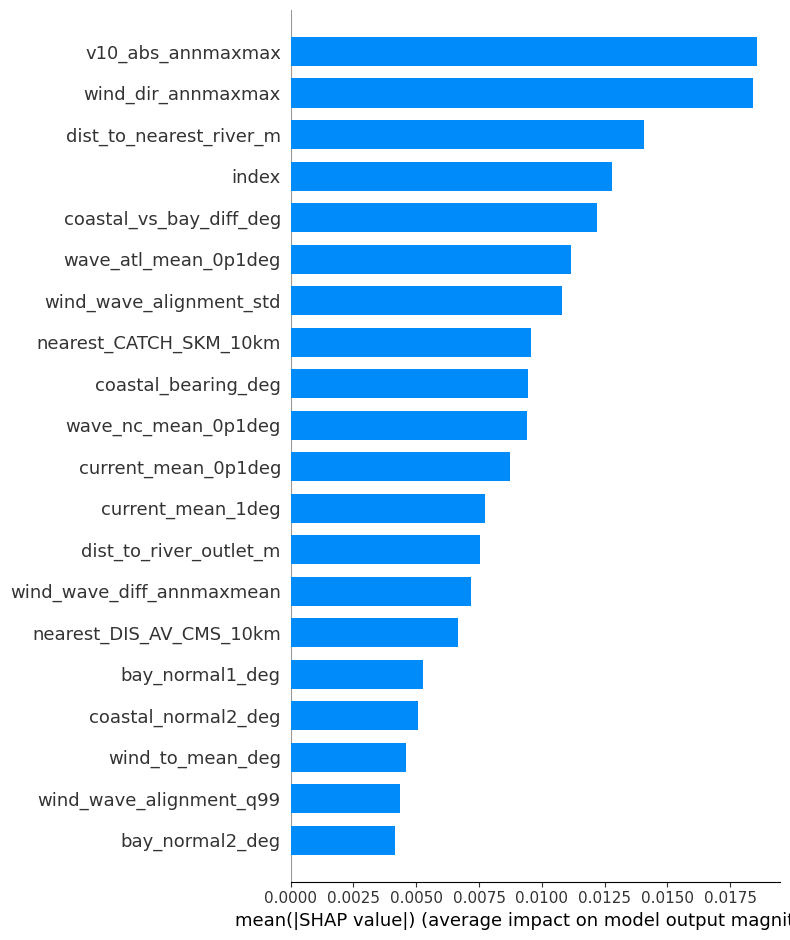

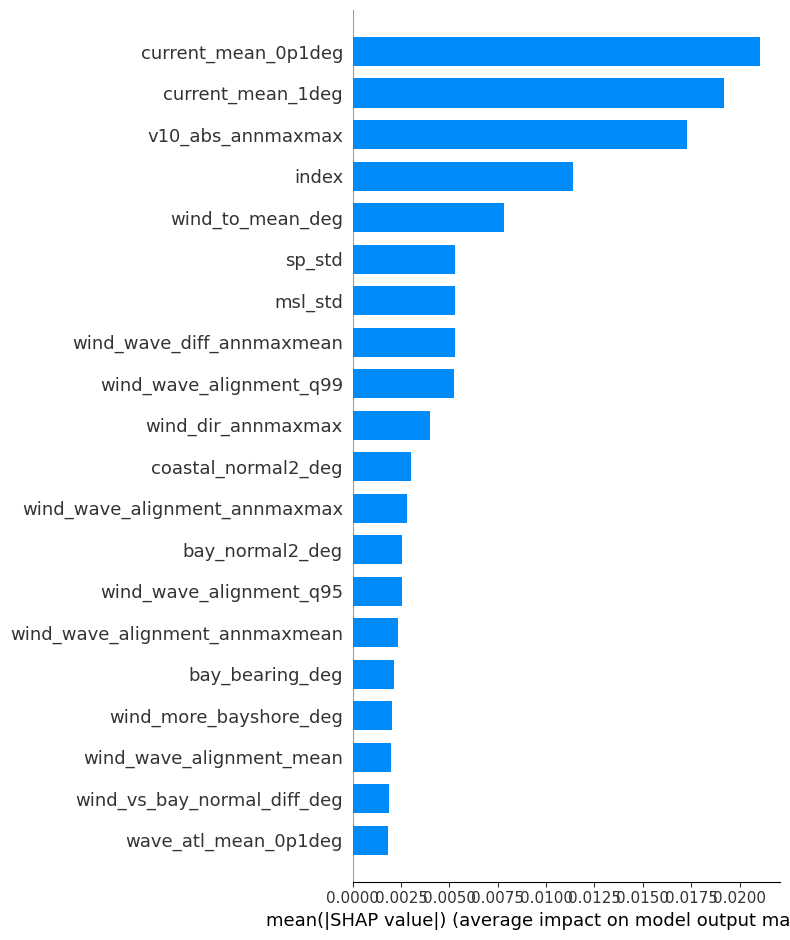

In [217]:
k = 0
# Select cluster k
shap_k = shap_exp[:, :, k]

shap.summary_plot(
    shap_k,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

k = 4
# Select cluster k
shap_k = shap_exp[:, :, k]

shap.summary_plot(
    shap_k,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)


In [218]:
print("\nTop variables separating cluster 4:\n")
print(cluster_importances[4].head(10))


Top variables separating cluster 4:

wind_dir_annmaxmax          0.044286
wind_wave_alignment_std     0.019286
wave_nc_mean_0p1deg         0.016429
wind_wave_diff_annmaxmax    0.012143
index                       0.006429
nearest_CATCH_SKM_10km      0.005000
current_mean_1deg           0.003571
coastal_vs_bay_diff_deg     0.002857
current_mean_0p1deg         0.001429
dist_to_CVI_m               0.000000
dtype: float64


In [219]:
coef = pd.DataFrame(
    logreg.coef_,
    columns=X.columns,
    index=[f"cluster_{k}" for k in logreg.classes_]
)

# Absolute importance per cluster
coef_abs = coef.abs()

print("\nTop linear separators for cluster 1:\n")
print(coef_abs.loc["cluster_1"].sort_values(ascending=False).head(5))
print("\nTop linear separators for cluster 2:\n")
print(coef_abs.loc["cluster_2"].sort_values(ascending=False).head(5))
print("\nTop linear separators for cluster 3:\n")
print(coef_abs.loc["cluster_3"].sort_values(ascending=False).head(5))



Top linear separators for cluster 1:

nearest_CATCH_SKM_10km         0.809237
nearest_DIS_AV_CMS_10km        0.576482
current_mean_0p1deg            0.535544
wind_vs_bay_normal_diff_deg    0.513625
index                          0.471064
Name: cluster_1, dtype: float64

Top linear separators for cluster 2:

current_mean_1deg      1.449944
wave_nc_mean_0p1deg    1.224646
index                  1.019545
wind_dir_annmaxmax     0.882168
v10_abs_annmaxmax      0.731457
Name: cluster_2, dtype: float64

Top linear separators for cluster 3:

wind_dir_annmaxmax      1.792380
v10_abs_annmaxmax       1.257324
coastal_normal2_deg     0.878952
wave_atl_mean_0p1deg    0.762886
index                   0.637798
Name: cluster_3, dtype: float64


In [220]:

print("\nTop linear separators for cluster 4:\n")
print(coef_abs.loc["cluster_4"].sort_values(ascending=False).head(5))
print("\nTop linear separators for cluster 6:\n")
print(coef_abs.loc["cluster_6"].sort_values(ascending=False).head(6))


Top linear separators for cluster 4:

wind_dir_annmaxmax          0.912147
dist_to_nearest_river_m     0.719693
wind_wave_alignment_q99     0.617823
wind_wave_diff_annmaxmax    0.498997
coastal_normal2_deg         0.443995
Name: cluster_4, dtype: float64

Top linear separators for cluster 6:

current_mean_1deg              1.427582
current_mean_0p1deg            0.838194
wave_nc_mean_0p1deg            0.816590
sp_std                         0.813713
msl_std                        0.810770
wind_vs_bay_normal_diff_deg    0.718209
Name: cluster_6, dtype: float64


In [221]:
print("\nTop variables separating cluster 6:\n")
print(cluster_importances[6].head(10))


Top variables separating cluster 6:

current_mean_0p1deg        0.020714
v10_abs_annmaxmax          0.015000
index                      0.013571
current_mean_1deg          0.013571
sp_std                     0.010714
nearest_DIS_AV_CMS_10km    0.009286
wind_wave_alignment_std    0.007857
wave_nc_mean_0p1deg        0.006429
wind_wave_alignment_q99    0.006429
msl_std                    0.005714
dtype: float64


In [222]:
print("\nTop variables separating cluster 3:\n")
print(cluster_importances[3].head(10))


Top variables separating cluster 3:

wind_dir_annmaxmax          0.071429
index                       0.025000
v10_abs_annmaxmax           0.024286
coastal_vs_bay_diff_deg     0.006429
coastal_bearing_deg         0.000714
nearest_CATCH_SKM_10km      0.000000
dist_to_river_outlet_m      0.000000
wave_nc_mean_0p1deg         0.000000
wind_wave_diff_annmaxmax    0.000000
coastal_normal1_deg         0.000000
dtype: float64


In [223]:
print("\nTop variables separating cluster 2:\n")
print(cluster_importances[1].head(10))


Top variables separating cluster 2:

nearest_DIS_AV_CMS_10km      0.037143
v10_abs_annmaxmax            0.030714
wind_wave_diff_annmaxmean    0.020714
index                        0.017857
wind_wave_alignment_q99      0.015714
msl_std                      0.015714
sp_std                       0.015000
wind_dir_annmaxmax           0.015000
coastal_bearing_deg          0.014286
coastal_normal1_deg          0.014286
dtype: float64


In [371]:
coef = pd.DataFrame(
    logreg.coef_,
    columns=X.columns,
    index=[f"cluster_{k}" for k in logreg.classes_]
)

# Absolute importance per cluster
coef_abs = coef.abs()

print("\nTop linear separators for cluster 1:\n")
print(coef_abs.loc["cluster_1"].sort_values(ascending=False).head(10))


ValueError: Shape of passed values is (5, 33), indices imply (5, 18)